In [1]:
#1 - Collegamento e clonazione repo GitHub, da fare ogni volta che si apre colab
#Clonazione repo (pulita)
!rm -rf provaTesi1
!git clone https://github.com/aindaorlando-coder/provaTesi1.git
%cd provaTesi1

# Config git
!git config --global user.name "aindaorlando-coder"
!git config --global user.email "ainda.orlando@gmail.com"

Cloning into 'provaTesi1'...
remote: Enumerating objects: 11829, done.
remote: Total 11829 (delta 0), reused 0 (delta 0), pack-reused 11829 (from 2)
Receiving objects: 100% (11829/11829), 8.02 MiB | 9.49 MiB/s, done.
Resolving deltas: 100% (7192/7192), done.
/content/provaTesi1


In [ ]:
#2 - setup iniziale, carico il datasetDelhi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("datasetDelhi.csv")
data.head()

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,1,1,2021,0,5,408.80,442.42,160.61,12.95,2.77,43.19,462
1,2,1,2021,0,6,404.04,561.95,52.85,5.18,2.60,16.43,482
2,3,1,2021,1,7,225.07,239.04,170.95,10.93,1.40,44.29,263
3,4,1,2021,0,1,89.55,132.08,153.98,10.42,1.01,49.19,207
4,5,1,2021,0,2,54.06,55.54,122.66,9.70,0.64,48.88,149


In [ ]:
#3 - Effettuo il controllo di completezza dei dati
print(data.info())

print("\nValori mancanti per colonna:")
print(data.isnull().sum())

print("\nPercentuale valori mancanti:")
print(data.isnull().mean() * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1461 non-null   int64  
 1   Month           1461 non-null   int64  
 2   Year            1461 non-null   int64  
 3   Holidays_Count  1461 non-null   int64  
 4   Days            1461 non-null   int64  
 5   PM2.5           1461 non-null   float64
 6   PM10            1461 non-null   float64
 7   NO2             1461 non-null   float64
 8   SO2             1461 non-null   float64
 9   CO              1461 non-null   float64
 10  Ozone           1461 non-null   float64
 11  AQI             1461 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 137.1 KB
None

Valori mancanti per colonna:
Date              0
Month             0
Year              0
Holidays_Count    0
Days              0
PM2.5             0
PM10              0
NO2               0
SO2             

In [ ]:
#4 - Definizione X e y del dataset Delhi
X = data[["PM2.5", "PM10", "NO2", "SO2", "CO", "Ozone"]]
y = data["AQI"]

In [ ]:
 #5 -suddivisione del dataset
 #80% per training (addestramento del modello)
 #20% per test (valutazione del modello)
 #random_state = 42 rende la divisione sempre uguale, per avere stessi risultati ossia per  garantire la riproducibilità dei risultati
 from sklearn.model_selection import train_test_split
 X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#6- Scaling - Standardizzo le variabili
# Scaling delle variabili (NO data leakage)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit SOLO sul training set
X_train_scaled = scaler.fit_transform(X_train)

# trasformo il test set
X_test_scaled = scaler.transform(X_test)

# converto in DataFrame (più leggibile)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

# controllo veloce
X_train_scaled.head()

,PM2.5,PM10,NO2,SO2,CO,Ozone
1066,-0.070501,0.807142,0.115966,-0.032495,0.613318,-1.665693
638,-0.759570,-0.488413,-0.782191,-0.627293,-0.562039,-1.427381
799,-0.419262,0.197324,-0.536506,-0.406488,-0.247507,0.378253
380,0.573439,0.082018,-0.895435,-1.120365,0.216014,-1.184365
303,0.706645,0.225933,0.522752,-0.874427,1.027176,0.172866


In [ ]:
# 7 - Modello di regressione lineare
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

# addestramento
model_lr.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
#8 - Predizioni
y_pred_lr = model_lr.predict(X_test_scaled)

In [ ]:
# 9 - Valutazione modello (REGRESSIONE)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))

Linear Regression MAE: 26.922718825665584
Linear Regression MSE: 1457.1636501727605
Linear Regression R²: 0.8877085002447455


In [ ]:
# 10 - Random Forest Regressor
# n_jobs=-1 significa usa tutti i core disponibili

from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)

In [ ]:
# 11 - Valutazione modello (Random Forest Regression)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE Random Forest Regression:", mean_absolute_error(y_test, y_pred))
print("MSE Random Forest Regression:", mean_squared_error(y_test, y_pred))
print("R² Random Forest Regression:", r2_score(y_test, y_pred))

MAE Random Forest Regression: 18.60423208191126
MSE Random Forest Regression: 847.6662143344711
R² Random Forest Regression: 0.9346774053221877


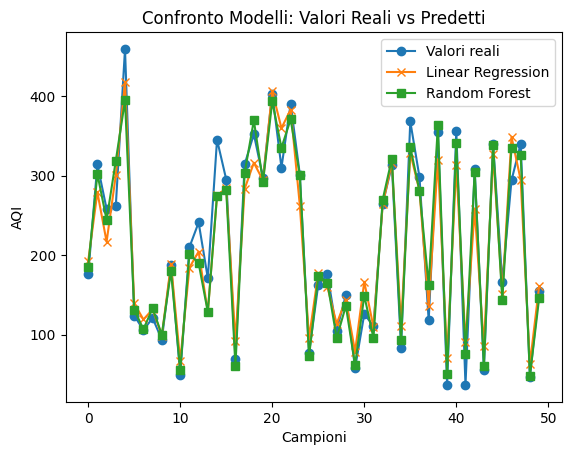

In [ ]:
# 12 - grafica dei risultati e confronto
import matplotlib.pyplot as plt

plt.figure()

# valori reali
plt.plot(y_test.values[:50], label="Valori reali", marker='o')

# predizioni Linear Regression
plt.plot(y_pred_lr[:50], label="Linear Regression", marker='x')

# predizioni Random Forest
plt.plot(y_pred_rf[:50], label="Random Forest", marker='s')

plt.title("Confronto Modelli: Valori Reali vs Predetti")
plt.xlabel("Campioni")
plt.ylabel("AQI")
plt.legend()
plt.show()

In [2]:
#codice per il salvataggio del notebook nella repo di GitHub
!pwd

/content/provaTesi1


In [3]:
!ls


agents		      hooks		       README.zh-CN.md
assets		      LICENSE		       ROADMAP.md
bin		      package.json	       scripts
CHANGELOG.md	      package-lock.json        sdk
commands	      PROJECT.md	       SECURITY.md
CONTRIBUTING.md       PrototipoPipeline.ipynb  STATE.md
datasetDelhi.csv      README.ja-JP.md	       tests
dataset_simulato.csv  README.ko-KR.md	       tsconfig.json
docs		      README.md		       VERSIONING.md
get-shit-done	      README.pt-BR.md	       vitest.config.ts


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
